When you want to test something, first you have to understand your H0 and H1
Supposing that H0 is True - > See with a test, how probable is it that the data arises from our Assumptions (H0 True)
Genes independent  + Data of Genes => Make permutation test
### p-value = is the probability to get a more extreme result than the one observed
Calculate p value (Permutations with more correlation than original data / amount of permutations)

In [14]:
import pandas as pd
from plotnine import *

growth_analysis = (pd.read_csv("growth_analysis.txt", sep = '\t')
.rename(columns = {'gene_5211': 'gene_A',
'gene_5091': 'gene_B',
'gene_1653': 'gene_C'})
.loc[:, ['strain', 'growth_rate', 'gene_A', 'gene_B', 'gene_C']])
growth_analysis.head()

,strain,growth_rate,gene_A,gene_B,gene_C
0,seg_01B,6.720447,False,False,True
1,seg_01C,7.429273,False,False,True
2,seg_01D,6.905589,True,True,False
3,seg_02B,4.924324,False,True,False
4,seg_02C,4.413402,False,False,True


a) A researcher collects data on the height (measured in cm) and weight (measured in g) of Germans.
She hypothesizes that there is a significant association between how tall Germans are and how much
they weigh. She would like to test this hypothesis without making any distributional assumptions.
- Probably not linearly correlated, so let's use Spearman

b) A researcher collects data on the weight (measured in g) of Bavarians before and after the Oktoberfest. She would like to know whether there is a significant difference in average weight after
2 the Oktoberfest as compared to before it. Prior research indicates that the weight of Bavarians is approximately normally distributed.

- Binary data but not sure if Normally distributed or not. t-test and

c) A researcher is evaluating a rapid antigen test. The company manufacturing the test claims that if
someone is infected, the test will correctly return a positive result 99% of the time. The researcher
hypothesizes that, in practice, the test is often improperly administered and therefore significantly
less sensitive. She asks 1000 individuals, which have all been confirmed to be infected by a PCR
test, to self-administer the antigen test. She records how often the antigen test correctly returns a
positive result.

- We would use binomial test for only one binary, x =  # antigen positive result
- This time, the assumption H0 that we are trying to test is that the medicine is 99% efficient. We would use left side test. We will be testing wheter the effectiveness per 1000 people is 990. The p value needs to be 99%.

d)  The company manufacturing the test has collected a bigger dataset, comprising both infected and
non-infected individuals. For each individual, they record two datapoints: the result of a PCR
test (infected/not-infected), which is taken as ground truth, and the result of a self-administered
antigen test (positive/negative). They would like to show that, even if self-administered, the test
still gives some information about infection status and thus is better than nothing.
- binary & binary -


| Test Name              | Variable 1 Type | Variable 2 Type | Purpose / What It Compares                               | Notes                              |
|------------------------|-----------------|-----------------|-----------------------------------------------------------|------------------------------------|
| **t-test (general)**   | Continuous      | Binary group     | Mean difference between two groups                        | Requires normality, equal variances |
| **Welch’s t-test**     | Continuous      | Binary group     | Mean difference between two groups (unequal variances)    | More robust than t-test            |
| **Mann–Whitney U**     | Continuous/Ordinal | Binary group  | Distribution / median difference between two groups       | Nonparametric                      |
| **Wilcoxon Signed-Rank** | Continuous/Ordinal (paired) | Condition (before/after) | Paired difference in medians                               | Nonparametric                      |
| **Pearson correlation** | Continuous     | Continuous      | Linear relationship                                       | Sensitive to outliers; requires linearity |
| **Spearman correlation** | Ordinal or Continuous | Ordinal or Continuous | Monotonic relationship                                    | Rank-based, nonparametric          |
| **Fisher’s Exact Test** | Binary/Category | Binary/Category | Association between two categorical variables             | For small samples (2×2 tables)     |


## Section 02

/home/artur/Documents/Coding/DataScience/.venv/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 4 rows containing non-finite values.


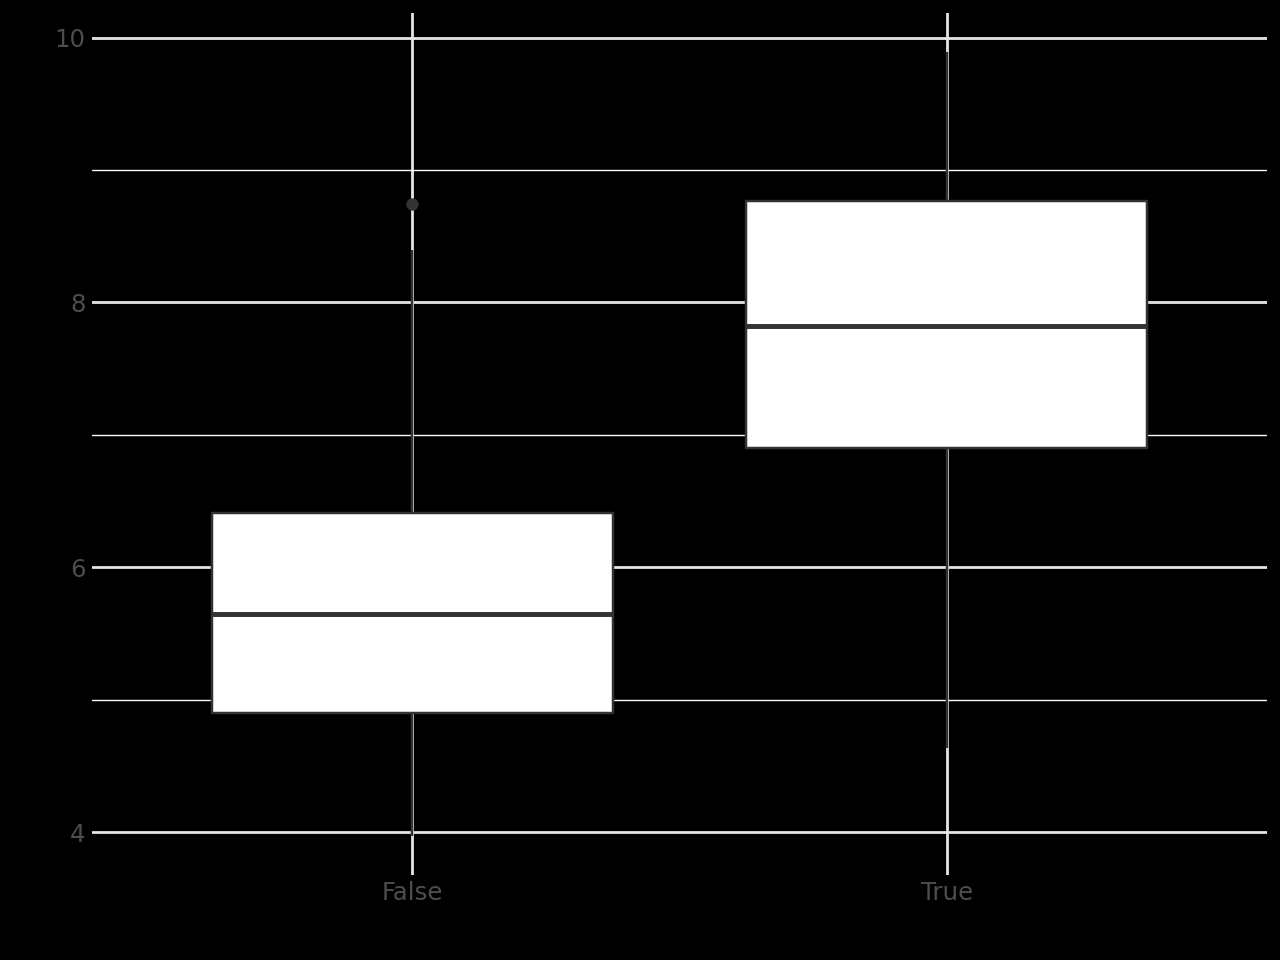

In [13]:
def plot_growth_one_mk(growth_analysis, gene):
    plot = (ggplot(growth_analysis, aes(gene, 'growth_rate')) +
            geom_boxplot() +
            xlab(f"Genotype at {gene}") +
            ylab("Growth rate in Maltose [Generations/day]") +
            theme_minimal()
            )
    return plot
plot_growth_one_mk(growth_analysis, 'gene_A')